In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/ABahadirAvcibas/ExamScore-Prediction-MachineLearning/refs/heads/main/StudentPerformanceFactors.csv"
rawData = pd.read_csv(url)

In [3]:
## Quick Look What we have?

In [4]:
rawData.shape  ## 6607 row - 20 column YANİ, 6607 tane değerimiz var ve her değerin 20 tane özelliği var

(6607, 20)

In [5]:
rawData.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [6]:
rawData.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [7]:
rawData.isna().any() # NULL CONTROL, checks if any value missing either True or False (isna), any() -> any value

,0
Hours_Studied,False
Attendance,False
Parental_Involvement,False
Access_to_Resources,False
Extracurricular_Activities,False
Sleep_Hours,False
Previous_Scores,False
Motivation_Level,False
Internet_Access,False
Tutoring_Sessions,False


In [8]:
rawData.describe() # Information about data

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [9]:
rawData["Internet_Access"].value_counts()  # Hangi cevaptan kaç tane var görebiliyoruz

,count
Internet_Access,
Yes,6108
No,499


In [10]:
rawData.isnull().sum() # Null olan değerler hangi columnda ne kadar var

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [11]:
## EDA

In [12]:
def plotRelation(data, col1, col2):
  x=data[col1]
  y=data[col2]
  plt.figure(figsize=(7,4))
  plt.scatter(x, y)
  plt.xlabel(col1)
  plt.ylabel(col2)
  plt.title(f"{col1} vs {col2}")
  plt.tight_layout()
  plt.show()

In [13]:
rawData[["Attendance", "Exam_Score"]].corr()

,Attendance,Exam_Score
Attendance,1.000000,0.581072
Exam_Score,0.581072,1.000000


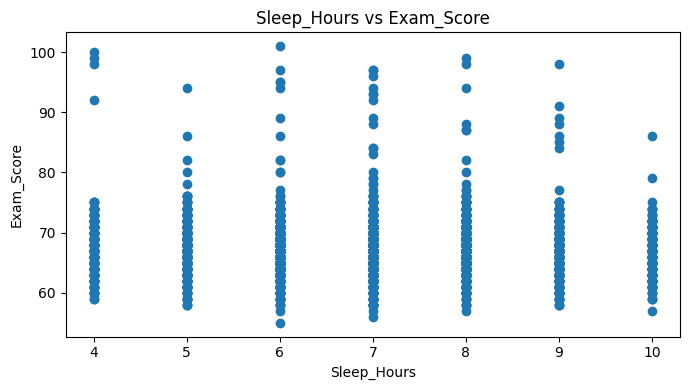

In [14]:
plotRelation(rawData, "Sleep_Hours", "Exam_Score")

In [15]:
## Teacher_Quality ## Parental_Education_Level ## Distance_from_Home

In [16]:
# Yukarıdaki columnlarda null değerler var şimdi onları halletmemiz lazım

In [17]:
rawData.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [18]:
rawData["Teacher_Quality"].value_counts() # Bu satır hangi seviyeyle null değerleri doldurmanın mantıklı olacağını anlamak için yapıldı.

,count
Teacher_Quality,
Medium,3925
High,1947
Low,657


In [19]:
data = rawData.copy()

In [20]:
data["Teacher_Quality"] = data["Teacher_Quality"].fillna("Medium")  # nulları "medium" ile doldur

In [21]:
data["Teacher_Quality"].value_counts()

,count
Teacher_Quality,
Medium,4003
High,1947
Low,657


In [22]:
data["Parental_Education_Level"].value_counts()

,count
Parental_Education_Level,
High School,3223
College,1989
Postgraduate,1305


In [23]:
data["Parental_Education_Level"] = data["Parental_Education_Level"].fillna("High School")

In [24]:
data["Parental_Education_Level"].value_counts()

,count
Parental_Education_Level,
High School,3313
College,1989
Postgraduate,1305


In [25]:
data["Distance_from_Home"].value_counts()

,count
Distance_from_Home,
Near,3884
Moderate,1998
Far,658


In [26]:
data["Distance_from_Home"] = data["Distance_from_Home"].fillna("Near")

In [27]:
data.isnull().sum()  # Artık null değer yok

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [28]:
# Ordinal Mapping
low_med_high = {"Low": 0, "Medium": 1, "High": 2}
dist_map = {"Near": 0, "Moderate": 1, "Far": 2}
edu_map = {"High School": 0, "College": 1, "Postgraduate": 2}
peer_map = {"Negative": 0, "Neutral": 1, "Positive": 2}

In [29]:
for c in ["Parental_Involvement", "Access_to_Resources", "Motivation_Level", "Family_Income", "Teacher_Quality"]:
    data[c] = data[c].map(low_med_high)

In [30]:
data["Distance_from_Home"] = data["Distance_from_Home"].map(dist_map)
data["Parental_Education_Level"] = data["Parental_Education_Level"].map(edu_map)
data["Peer_Influence"] = data["Peer_Influence"].map(peer_map)

In [31]:
# 3) Nominal columns -> One-Hot
nominal_cols = ["Extracurricular_Activities", "Internet_Access", "School_Type", "Learning_Disabilities", "Gender"]

In [32]:
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=int)

In [33]:
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
0,23,84,0,2,7,73,0,0,0,1,2,3,0,0,67,0,1,1,0,1
1,19,64,0,1,8,59,0,2,1,1,0,4,1,1,61,0,1,1,0,0
2,24,98,1,1,7,91,1,2,1,1,1,4,2,0,74,1,1,1,0,1
3,29,89,0,1,8,98,1,1,1,1,0,4,0,1,71,1,1,1,0,1
4,19,92,1,1,6,65,1,3,1,2,1,4,1,0,70,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,2,1,7,76,1,1,2,1,2,2,0,0,68,0,1,1,0,0
6603,23,76,2,1,8,81,1,3,0,2,2,2,0,0,69,0,1,1,0,0
6604,20,90,1,0,6,65,0,3,0,1,0,2,2,0,68,1,1,1,0,0
6605,10,86,2,2,6,91,2,2,0,1,2,3,0,2,68,1,1,0,0,0


In [34]:
# Artık bütün veriler rakam

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [37]:
x = data.drop(columns=["Exam_Score"])
y = data["Exam_Score"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=94)

In [43]:
lin_model = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

In [44]:
# Train
lin_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [45]:
y_pred = lin_model.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

MAE : 0.479
RMSE: 2.032
R2  : 0.714


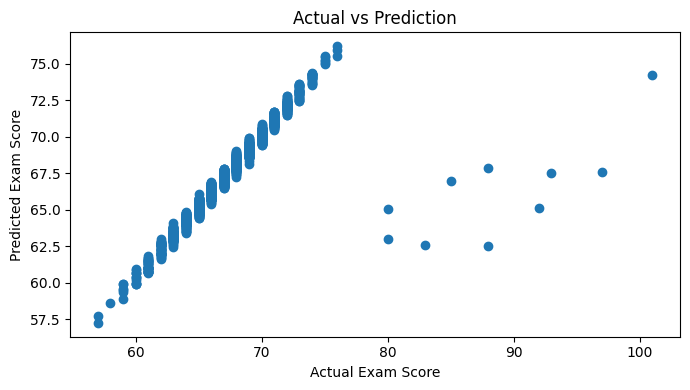

In [55]:
plt.figure(figsize=(7,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Prediction")
plt.tight_layout()
plt.show()